<a href="https://colab.research.google.com/github/danielcsjunqueira/pgrad_pucrio_datascience2/blob/main/Pos_Graduacao_PUCRio_Sprint_Machine_Learning_%26_Analytics_Daniel_Junqueira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nome:** Daniel Cardoso e Silva Junqueira

**Matrícula:** 4052026000062

**Data:** 04/07/2026

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

**Link do dataset (raw, GitHub):** https://raw.githubusercontent.com/danielcsjunqueira/pgrad_pucrio_datascience/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv

**Tipo de problema:** Classificação (binária) — previsão de churn (cancelamento) de clientes

**Porque a escolha da base e do Problema:** Trabalhei com consultoria em telecom há anos e hoje estou trabalhando diretamente dentro de uma grande empresa de telecom. Tive experiência com análise de tráfego e revenue assurance (garantia da receita). Essa experiência prévia me ajudou para trazer as hipóteses para serem validadas na análise desse MVP.

Para esse MVP foi utilizado o Visual Studio Code para diversas análises, testes e organização. Posteriormente organizado o 'storytelling' aqui no colab para publicação.

---

> **Continuidade:** Este colab notebook dá continuidade ao MVP da Sprint de Análise de Dados e Boas Práticas, que utilizou o mesmo dataset (Telco Customer Churn) para uma análise exploratória ([link colab Analise Exploratória](https://colab.research.google.com/drive/1hPoTHY63NOLEJJY6WSsY01FlsTD-mCSV#scrollTo=NFi5tEpeYlin)). Neste notebook, o foco passa a ser o desenvolvimento completo de um pipeline de Machine Learning: preparação dos dados, definição de baseline, treinamento e comparação de modelos candidatos, otimização de hiperparâmetros e avaliação crítica dos resultados.

> **Como executar:** este notebook foi desenvolvido para ser executado do início ao fim no Google Colab, sem necessidade de upload manual de arquivos, login ou chave de API. O dataset é carregado diretamente pela URL pública (*raw*) do repositório do GitHub indicado acima.

# 1. Definição do problema

## 1.1 Contexto

O churn (cancelamento) de clientes é um dos principais desafios enfrentados por empresas de telecomunicações. A entrada de um novo cliente costuma ser mais caro do que reter um cliente existente, o que torna a previsão de churn uma ferramenta estratégica valiosa: ao identificar antecipadamente quais clientes têm maior probabilidade de cancelar o serviço, a empresa pode direcionar ações de retenção (descontos, contato proativo, mudança de plano etc.) de forma mais eficiente.

Este MVP utiliza o dataset **Telco Customer Churn**, disponibilizado publicamente no Kaggle, contendo informações demográficas, de serviços contratados e financeiras de 7.043 clientes de uma empresa de telecomunicações.

## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning capazes de prever se um cliente irá cancelar o serviço (Churn) a partir de suas características demográficas, dos serviços contratados e do seu histórico financeiro, comparando uma abordagem *baseline* com modelos candidatos mais sofisticados e discutindo criticamente seus resultados e limitações.


## 1.3 Variável-alvo

A variável a ser prevista é **Churn**, que assume os valores:
- Yes (convertido para '1'): o cliente cancelou o serviço;
- No (convertido para '0'): o cliente permaneceu ativo.

## 1.4 Tipo de problema

**Tipo escolhido:** Classificação binária (aprendizado supervisionado).

**Justificativa:** a variável-alvo ('Churn') é categórica com apenas duas classes possíveis (cancelou / não cancelou). Não se trata de um valor numérico contínuo (o que descartaria regressão), não há ausência de rótulo conhecido (o que descartaria clusterização), e não há uma componente temporal explícita de previsão de valores futuros no problema — cada linha representa um cliente em um único instante, não uma série temporal de observações. Portanto, classificação supervisionada foi escolhida para esse problema.

## 1.5 Premissas, hipóteses e restrições

**Hipóteses iniciais** (algumas já observadas na análise exploratória da sprint anterior):
1. Clientes com contrato mensal (*Month-to-month*) apresentam maior taxa de churn do que clientes com contratos anuais ou bienais.
2. Clientes com pouco tempo de casa ('tenure' baixo) têm maior probabilidade de cancelar.
3. Clientes com mensalidades ('MonthlyCharges') mais altas tendem a cancelar mais.
4. Serviços adicionais (segurança online, suporte técnico, backup) podem estar associados a menor churn, por aumentarem o valor percebido do serviço.

**Restrições consideradas:**
- O identificador 'customerID' não deve ser utilizado como atributo preditivo, pois é apenas uma chave única sem poder preditivo real — usá-lo poderia introduzir overfitting ao identificador.
- A base apresenta desbalanceamento de classes (aproximadamente 73% "Não Churn" vs. 27% "Churn"), o que exige cuidado na escolha das métricas de avaliação (acurácia isoladamente não é suficiente).
- O dataset é uma fotografia estática (*snapshot*) dos clientes, sem dimensão temporal explícita — não é possível prever *quando* o churn ocorrerá, apenas se é provável que ocorra.

## 1.6 Critérios de sucesso

- **Métrica principal:** ROC-AUC (Area Under the ROC Curve), por ser robusta a desbalanceamento de classes e por permitir comparar modelos independentemente do limiar de decisão escolhido.
- **Métricas complementares:** F1-score da classe positiva (churn), recall (capacidade de identificar clientes que de fato cancelarão) e matriz de confusão.
- **Resultado mínimo esperado:** os modelos candidatos devem superar o baseline (que prevê sempre a classe majoritária) em ROC-AUC e em F1-score da classe minoritária.
- **Restrição para MVP na prática:** os modelos devem ser treináveis em poucos minutos em ambiente Colab padrão (sem GPU), mantendo o MVP simples e reproduzível.

# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção reúne as importações necessárias, a configuração de seed para reprodutibilidade e informações do ambiente de execução.

**Bibliotecas utilizadas:**
- 'pandas', 'numpy' — manipulação de dados;
- 'matplotlib', 'seaborn' — visualização;
- 'scikit-learn' — pré-processamento, modelagem, validação e otimização de hiperparâmetros;
- 'scipy' — distribuições estatísticas utilizadas na busca aleatória de hiperparâmetros.

Nenhuma dependência externa adicional é necessária: todas as bibliotecas já estão disponíveis por padrão no ambiente do Google Colab.

In [1]:
# === Setup básico e reprodutibilidade ===
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from scipy.stats import randint, uniform

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_style("whitegrid")

print("Python:", sys.version.split()[0])
print("Seed utilizada:", SEED)

Python: 3.12.13
Seed utilizada: 42


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados



- **Nome do dataset:** Telco Customer Churn.
- **Fonte original:** [Kaggle — blastchar/telco-customer-churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn).
- **Motivo da escolha:** dataset real de negócio (telecomunicações), com um problema de churn amplamente relevante para a área de Analytics, contendo uma combinação de variáveis numéricas e categóricas que exige decisões de pré-processamento não triviais.
- **Licença/uso:** dataset público, amplamente utilizado para fins educacionais e de pesquisa em Ciência de Dados. O `customerID` é um código interno de sistema, sem correspondência a dados pessoais reais.
- **Carga:** o arquivo CSV está hospedado em um repositório público do GitHub e é carregado diretamente pela URL *raw*, permitindo a execução do notebook do início ao fim sem upload manual, login ou chave de API.



## 3.2 Carga dos dados

In [37]:
# === Carga dos dados ===
URL = "https://raw.githubusercontent.com/danielcsjunqueira/pgrad_pucrio_datascience2/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(URL)

print("Formato do dataset:", df.shape)
df.head()

Formato do dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3.3 Dicionário de dados

| Coluna | Tipo | Descrição | Usada no modelo? |
|---|---|---|---|
| customerID | identificador | Código único do cliente | Não (removida — sem poder preditivo) |
| gender | categórica | Gênero do cliente (Male/Female) | Sim |
| SeniorCitizen | numérica binária | Indica se o cliente é idoso (1) ou não (0) | Sim |
| Partner | categórica | Possui parceiro(a)/cônjuge (Yes/No) | Sim |
| Dependents | categórica | Possui dependentes (Yes/No) | Sim |
| tenure | numérica | Meses de permanência na empresa | Sim |
| PhoneService | categórica | Possui serviço de telefonia (Yes/No) | Sim |
| MultipleLines | categórica | Possui múltiplas linhas telefônicas | Sim |
| InternetService | categórica | Provedor de internet (DSL, Fiber optic, No) | Sim |
| OnlineSecurity | categórica | Serviço de segurança online | Sim |
| OnlineBackup | categórica | Serviço de backup online | Sim |
| DeviceProtection | categórica | Seguro de dispositivo | Sim |
| TechSupport | categórica | Suporte técnico prioritário | Sim |
| StreamingTV | categórica | Streaming de TV | Sim |
| StreamingMovies | categórica | Streaming de filmes | Sim |
| Contract | categórica | Tipo de contrato (Month-to-month, One year, Two year) | Sim |
| PaperlessBilling | categórica | Fatura digital (Yes/No) | Sim |
| PaymentMethod | categórica | Forma de pagamento | Sim |
| MonthlyCharges | numérica | Valor cobrado mensalmente | Sim |
| TotalCharges | numérica | Valor total cobrado (histórico) — requer tratamento (Seção 3.5) | Sim |
| **Churn** | **alvo** | **Indica se o cliente cancelou o serviço (Yes/No)** | **Alvo** |


## 3.4 Visão geral do dataset

In [3]:
# === Visão geral do dataset ===
print("Tipos de dados:")
display(df.dtypes.to_frame("tipo"))

print("\nValores ausentes por coluna (contagem direta):")
display(df.isna().sum().to_frame("ausentes"))

print("\nDuplicatas:", df.duplicated().sum())
print("Clientes únicos (customerID):", df["customerID"].nunique(), "de", len(df), "linhas")

Tipos de dados:


,tipo
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Valores ausentes por coluna (contagem direta):


,ausentes
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Duplicatas: 0
Clientes únicos (customerID): 7043 de 7043 linhas


## 3.5 Tratamento de qualidade de dados: 'TotalCharges'

A coluna 'TotalCharges' é lida pelo pandas como texto ('object'), embora represente um valor monetário. Isso ocorre porque alguns registros contêm um caractere de espaço em branco ('" "') no lugar de um número — tipicamente clientes com 'tenure = 0', ou seja, clientes muito recentes que ainda não completaram um ciclo de cobrança.

Como esses valores não são 'NaN' (Not a number) no sentido estrito do pandas (são strings com espaço), eles **não** aparecem na contagem de ausentes acima. É necessário convertê-los explicitamente para numérico e tratar os valores resultantes como ausentes — este é um cuidado adicional em relação à etapa exploratória.

In [5]:
# Conversão de TotalCharges para numérico (valores não numéricos viram NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

n_missing = df["TotalCharges"].isna().sum()
print(f"Valores ausentes em TotalCharges após conversão: {n_missing}")

df.loc[df["TotalCharges"].isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Valores ausentes em TotalCharges após conversão: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


Confirmando a hipotese acima que todos os registros com 'TotalCharges' ausente correspondem a clientes com 'tenure = 0' (clientes muito novos, ainda no primeiro ciclo de cobrança). Nesses casos, o valor total cobrado até o momento é, de fato, próximo de zero — portanto, a imputação mais coerente é 'TotalCharges = 0' para esses registros, em vez de usar a mediana geral da coluna (o que distorceria o significado da variável para esse subgrupo específico).

In [6]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Valores ausentes em TotalCharges após tratamento:", df["TotalCharges"].isna().sum())

Valores ausentes em TotalCharges após tratamento: 0


# 4. Análise exploratória dos dados

Esta seção reaproveita e amplia parte da análise exploratória já realizada no MVP da sprint de Análise de Dados e Boas Práticas, com foco agora nos aspectos mais relevantes para a etapa de modelagem: distribuição do target, desbalanceamento de classes e relação entre as principais variáveis e o churn.


## 4.1 Distribuição do target

Distribuição do target (Churn):


,contagem,percentual (%)
Churn,,
No,5174,73.46
Yes,1869,26.54


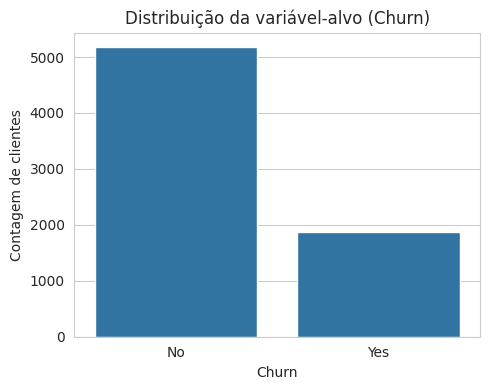

In [7]:
target_counts = df["Churn"].value_counts()
target_pct = (df["Churn"].value_counts(normalize=True) * 100).round(2)

print("Distribuição do target (Churn):")
display(pd.DataFrame({"contagem": target_counts, "percentual (%)": target_pct}))

plt.figure(figsize=(5, 4))
sns.countplot(x="Churn", data=df, order=["No", "Yes"])
plt.title("Distribuição da variável-alvo (Churn)")
plt.xlabel("Churn")
plt.ylabel("Contagem de clientes")
plt.tight_layout()
plt.show()

O dataset apresenta desbalanceamento moderado: aproximadamente 73% dos clientes não cancelaram o serviço, enquanto cerca de 27% cancelaram. Esse desbalanceamento não é extremo, mas é suficiente para que a acurácia isolada seja uma métrica enganosa — um modelo "preguiçoso" que sempre prevê "No" já acertaria ~73% das vezes sem aprender nada útil. Por isso, ROC-AUC, F1-score e recall da classe positiva serão priorizados na avaliação.

## 4.2 Distribuições de variáveis numéricas

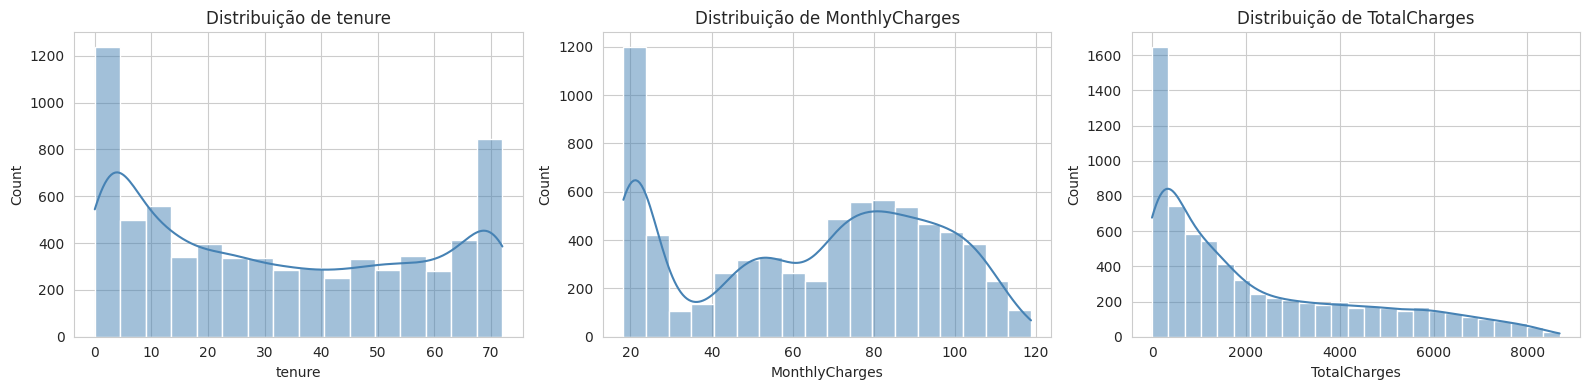

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [8]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribuição de {col}")
plt.tight_layout()
plt.show()

df[num_cols].describe()

- 'tenure' (meses de permanência) tem distribuição aproximadamente bimodal, com muitos clientes muito novos (poucos meses) e um segundo grupo de clientes de longa data (próximo dos 72 meses, teto do dataset).
- 'MonthlyCharges' também apresenta distribuição multimodal, refletindo os diferentes pacotes de serviço oferecidos (planos básicos vs. planos com internet fibra + serviços adicionais).
- 'TotalCharges' é fortemente concentrado em valores baixos, o que é esperado, já que é aproximadamente o produto de 'tenure' por 'MonthlyCharges' — ou seja, há forte correlação esperada entre essas variáveis.



## 4.3 Variáveis numéricas x churn

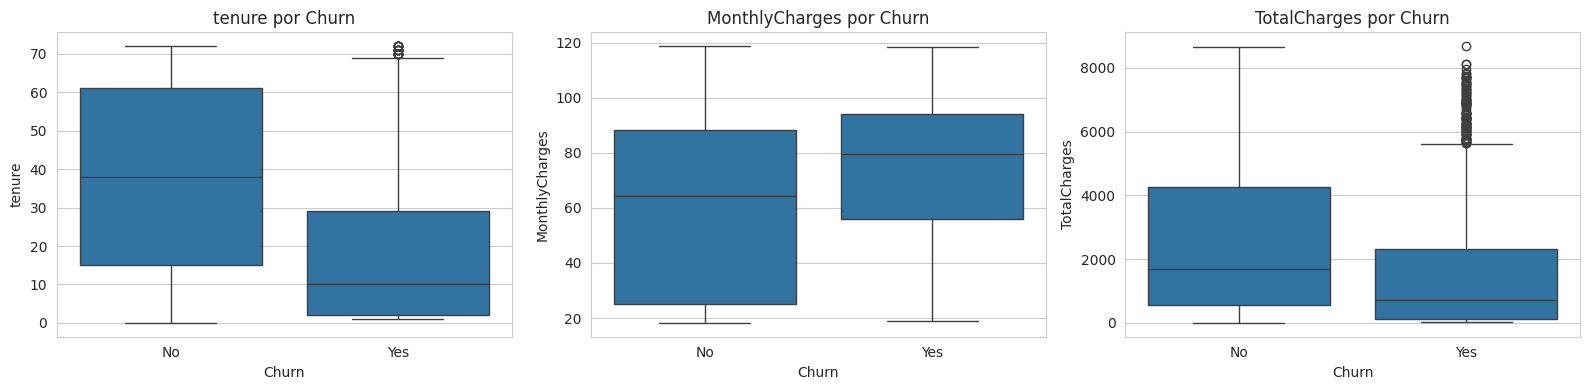

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(x="Churn", y=col, data=df, order=["No", "Yes"], ax=ax)
    ax.set_title(f"{col} por Churn")
plt.tight_layout()
plt.show()

Confirma-se a hipótese inicial: clientes que cancelam tendem a ter **menor tempo de permanência ('tenure')** e **mensalidades ('MonthlyCharges') mais altas** do que os clientes que permanecem. Já 'TotalCharges' tende a ser menor entre quem cancela, o que é consistente com o menor tempo de casa desses clientes.

## 4.4 Correlação entre variáveis numéricas

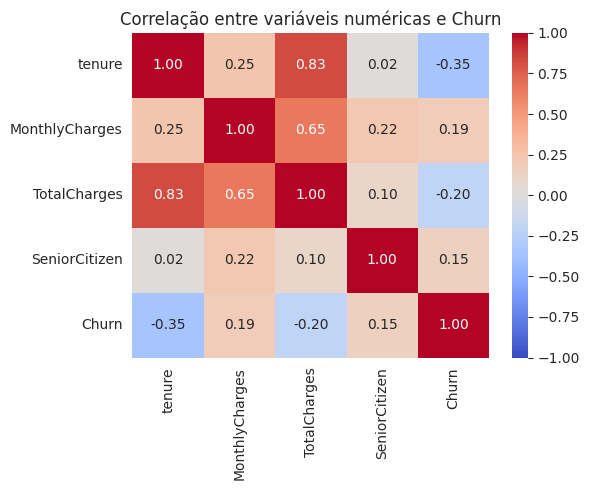

In [10]:
corr_df = df[num_cols + ["SeniorCitizen"]].copy()
corr_df["Churn"] = (df["Churn"] == "Yes").astype(int)
corr = corr_df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlação entre variáveis numéricas e Churn")
plt.tight_layout()
plt.show()

Como esperado com as análises até aqui, 'tenure' e 'TotalCharges' são fortemente correlacionadas (clientes com mais tempo de casa acumulam mais cobrança total). 'tenure' apresenta correlação negativa com o churn (quanto mais tempo de casa, menor a chance de cancelar), enquanto 'MonthlyCharges' apresenta correlação positiva (mensalidades mais altas, maior chance de cancelar). Essa forte correlação entre 'tenure' e 'TotalCharges' é levada em conta na modelagem, mas não justifica a remoção de nenhuma delas neste MVP, já que os modelos escolhidos (árvores/ensembles e regressão logística regularizada) epera-se que lidem razoavelmente bem com colinearidade moderada.

## 4.5 Variáveis categóricas x churn

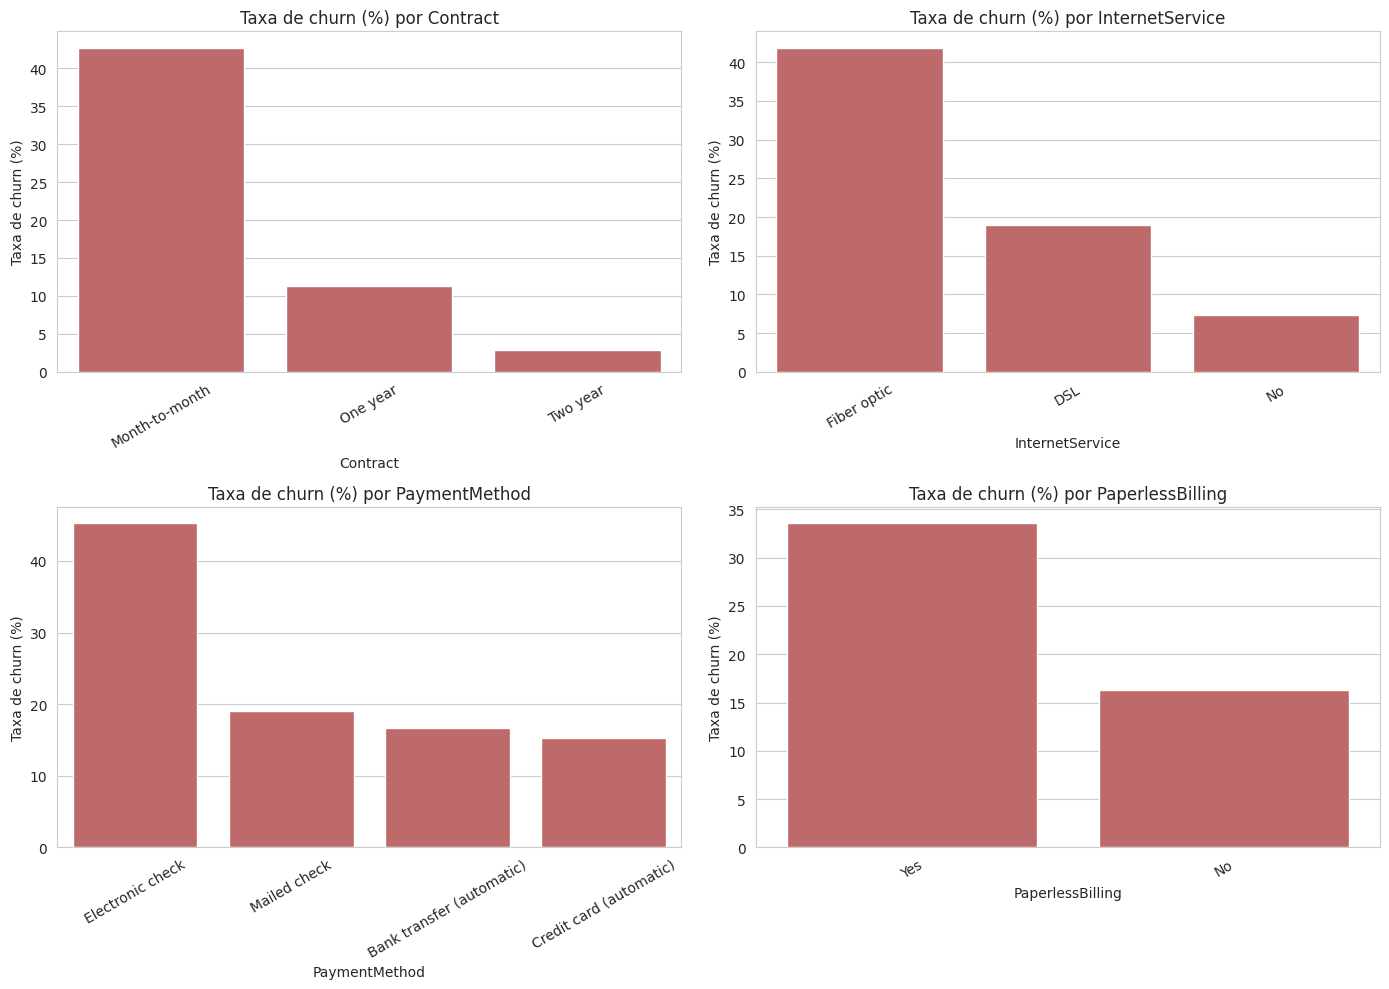

In [11]:
cat_cols_plot = ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), cat_cols_plot):
    churn_rate = (
        df.groupby(col)["Churn"]
        .apply(lambda s: (s == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )
    sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=ax, color="indianred")
    ax.set_title(f"Taxa de churn (%) por {col}")
    ax.set_ylabel("Taxa de churn (%)")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

- **Contrato mensal ('Month-to-month')** apresenta a maior taxa de churn, muito acima dos contratos anuais e bienais — confirmando a hipótese inicial de que a flexibilidade de cancelamento (sem fidelidade) está associada a maior evasão.
- **Fibra óptica ('Fiber optic')** como serviço de internet apresenta churn mais alto do que DSL ou "sem internet" — possivelmente relacionado à maior mensalidade ou a problemas de qualidade/preço percebido.
- **Pagamento por *electronic check*** apresenta churn nitidamente mais alto do que os métodos automáticos (cartão de crédito, débito automático), sugerindo menor engajamento/fidelização de clientes que pagam manualmente.
- **Fatura digital ('PaperlessBilling = Yes')** também está associada a maior churn.

## 4.6 Síntese da análise exploratória

**Principais achados:**
1. O target é moderadamente desbalanceado (~27% churn) — métricas sensíveis a desbalanceamento serão priorizadas na modelagem.
2. Não havia valores ausentes "clássicos", mas foi identificado e corrigido um problema de qualidade em 'TotalCharges' (texto com espaço em branco).
3. 'tenure' baixo, 'MonthlyCharges' alto e contrato mensal são os sinais mais fortes de propensão ao churn.
4. Há forte correlação entre 'tenure' e 'TotalCharges', mas isso não impede seu uso conjunto nos modelos escolhidos.
5. Forma de pagamento e tipo de fatura também discriminam bem o churn, sendo mantidas no conjunto de features.

Esses achados orientam diretamente as decisões de preparação e modelagem a seguir.

# 5. Preparação dos dados e divisão treino/teste

## 5.1 Definição de features e target

O identificador 'customerID' é removido do conjunto de features, pois é uma chave única sem poder preditivo genuíno; mantê-lo poderia, na prática, ser ignorado pelos modelos (por ser praticamente único por linha) ou, em cenários de vazamento, causar overfitting.

O target 'Churn' (texto "Yes"/"No") é convertido para valores binários ("1"/"0") para uso nos modelos de classificação do 'scikit-learn'.

In [12]:
TARGET = "Churn"
ID_COLUMNS = ["customerID"]

df_model = df.drop(columns=ID_COLUMNS).copy()
df_model[TARGET] = (df_model[TARGET] == "Yes").astype(int)

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

num_features = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_features = [c for c in X.columns if c not in num_features]

print("Número de features:", X.shape[1])
print("Features numéricas:", num_features)
print("Features categóricas:", cat_features)

Número de features: 19
Features numéricas: ['tenure', 'MonthlyCharges', 'TotalCharges']
Features categóricas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 5.2 Divisão treino/teste

A divisão é feita com **holdout estratificado** (80% treino / 20% teste), mantendo a proporção de churn em ambos os conjuntos. Como já comentado anteriormente, não há componente temporal no problema (cada linha é um cliente em um único instante), portanto não é necessário respeitar ordem cronológica, como poderia ser no caso em séries temporais.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Treino:", X_train.shape, "| Taxa de churn no treino:", round(y_train.mean() * 100, 2), "%")
print("Teste :", X_test.shape, "| Taxa de churn no teste :", round(y_test.mean() * 100, 2), "%")

Treino: (5634, 19) | Taxa de churn no treino: 26.54 %
Teste : (1409, 19) | Taxa de churn no teste : 26.54 %


## 5.3 Pipeline de pré-processamento


Para evitar vazamento de dados, todo o pré-processamento (imputação, padronização, codificação) é encapsulado em um 'Pipeline'/'ColumnTransformer' do 'scikit-learn', ajustado **apenas** com os dados de treino a cada chamada de '.fit()' — inclusive dentro da validação cruzada e da busca de hiperparâmetros.

**Decisões tomadas:**
- **Variáveis numéricas** ('tenure', 'MonthlyCharges', 'TotalCharges'): imputação pela mediana (robusta a outliers) seguida de padronização ('StandardScaler'), necessária para os modelos sensíveis à escala (Regressão Logística, KNN).
- **Variáveis categóricas** (demográficas, serviços contratados, contrato, forma de pagamento etc.): OneHotEncoder com handle_unknown="ignore", evitando erros caso alguma categoria rara não apareça no treino. Optou-se por One-Hot em vez de Label Encoding simples (usado na etapa exploratória no MVP anterior de Analise Exploratória - com link no início) porque a maioria dessas variáveis é **nominal** (sem ordem natural entre categorias, como 'InternetService' ou 'PaymentMethod'); usar Label Encoding introduziria uma ordinalidade artificial que poderia confundir modelos lineares como a Regressão Logística.
- 'SeniorCitizen' já é uma variável binária (0/1) e é tratada como numérica, sem necessidade de codificação adicional.

In [16]:
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_features),
    ("cat", categorical_pipe, cat_features)
], remainder="drop")

preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

# 6. Baseline e modelos candidatos


Nesta seção, define-se um baseline simples e um conjunto de modelos candidatos (Regressão Logística e Random Forest).

**Baseline:** 'DummyClassifier' com estratégia 'most_frequent' — sempre prevê a classe majoritária (não churn). Serve como referência mínima: qualquer modelo real precisa superá-lo, especialmente em métricas sensíveis ao desbalanceamento (F1 e ROC-AUC da classe positiva).

**Modelos candidatos:**
1. **Regressão Logística** ('class_weight="balanced"') — modelo linear, interpretável, bom ponto de partida para problemas de classificação binária tabular.
2. **Random Forest** — ensemble de árvores, captura relações não lineares e interações entre variáveis sem necessidade de normalização.
3. **Gradient Boosting** *(modelo adicional, além do template)* — ensemble sequencial de árvores fracas, frequentemente um dos modelos com melhor desempenho em dados tabulares estruturados como este.
4. **K-Nearest Neighbors (KNN)** *(modelo adicional, além do template)* — modelo baseado em distância, não paramétrico, incluído como uma abordagem de natureza distinta dos modelos baseados em árvore/lineares, para efeito de comparação.

**Justificativa da escolha:** os quatro modelos cobrem famílias distintas de algoritmos (linear, ensemble de bagging, ensemble de boosting e baseado em distância), permitindo uma comparação mais rica do que usar apenas variações de uma mesma família. Todos são nativos do 'scikit-learn', o que mantém o MVP enxuto e sem dependências externas.

In [17]:
baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

candidates = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=SEED))
    ]),
    "GradientBoosting": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingClassifier(random_state=SEED))
    ]),
    "KNN": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", KNeighborsClassifier())
    ]),
}

print("Modelos candidatos:", list(candidates.keys()))

Modelos candidatos: ['LogisticRegression', 'RandomForest', 'GradientBoosting', 'KNN']


# 7. Treinamento e avaliação inicial (validação cruzada)

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = ["accuracy", "f1", "roc_auc", "recall", "precision"]

cv_results = {}

t0 = time.time()
baseline_scores = cross_validate(baseline, X_train, y_train, cv=cv, scoring=scoring)
cv_results["Baseline (DummyClassifier)"] = {m: baseline_scores[f"test_{m}"].mean() for m in scoring}
cv_results["Baseline (DummyClassifier)"]["fit_time_s"] = round(baseline_scores["fit_time"].mean(), 3)

for name, model in candidates.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    cv_results[name] = {m: scores[f"test_{m}"].mean() for m in scoring}
    cv_results[name]["fit_time_s"] = round(scores["fit_time"].mean(), 3)

print("Tempo total de validação cruzada: %.1f s" % (time.time() - t0))

cv_results_df = pd.DataFrame(cv_results).T.sort_values("roc_auc", ascending=False)
cv_results_df

Tempo total de validação cruzada: 18.8 s


,accuracy,f1,roc_auc,recall,precision,fit_time_s
GradientBoosting,0.803518,0.588192,0.848229,0.529097,0.662743,1.223
LogisticRegression,0.748493,0.628250,0.845994,0.801338,0.516912,0.437
RandomForest,0.786300,0.533171,0.819592,0.460201,0.634783,1.166
KNN,0.765709,0.546553,0.782128,0.532441,0.561746,0.045
Baseline (DummyClassifier),0.734647,0.000000,0.500000,0.000000,0.000000,0.205



Antes de avaliar no conjunto de teste (que deve ser reservado para a avaliação final), realiza-se uma comparação inicial via **validação cruzada estratificada (5 folds)** no conjunto de treino, usando múltiplas métricas. Isso evita utilizar o teste repetidamente para decisões de modelagem, reduzindo o risco de overfitting ao próprio conjunto de teste.

## 7.1 Análise dos resultados iniciais

Espera-se que o baseline apresente ROC-AUC próximo de 0,50 (equivalente a uma escolha aleatória) e F1-score da classe positiva igual a 0, já que ele nunca prevê churn — evidenciando por que a acurácia isolada não é uma métrica confiável neste problema (o baseline pode atingir acurácia relativamente alta, próxima de 73%, mesmo sem nenhuma capacidade preditiva real).

Entre os modelos candidatos, espera-se que **Gradient Boosting** e **Regressão Logística** apresentem os melhores valores de ROC-AUC, por lidarem bem com a relação entre as variáveis mais discriminantes ('tenure', 'MonthlyCharges', 'Contract') e o target. O **KNN** tende a ser mais sensível à alta dimensionalidade introduzida pelo One-Hot Encoding (muitas colunas esparsas), podendo apresentar desempenho inferior aos demais. O **Random Forest** tende a ficar em posição intermediária, com desempenho consistente, mas sem necessariamente superar o Gradient Boosting.

Os valores numéricos reais devem ser lidos diretamente na tabela 'cv_results_df' gerada ao executar este notebook, já que dependem da execução completa do pipeline com os dados reais.

# 8. Otimização de hiperparâmetros


Escolhe-se o **Gradient Boosting** para a etapa de otimização de hiperparâmetros, por ser tipicamente um dos modelos mais sensíveis (e mais responsivos) a ajustes finos entre os candidatos avaliados, e por ter apresentado, na validação cruzada inicial, resultados competitivos.

**Hiperparâmetros ajustados:**
- 'n_estimators': número de árvores do ensemble;
- 'learning_rate': taxa de aprendizado (contribuição de cada árvore);
- 'max_depth': profundidade máxima de cada árvore;
- 'min_samples_leaf': número mínimo de amostras em cada folha (efeito de regularização);
- 'subsample': fração de amostras usada em cada árvore (efeito adicional de regularização por subamostragem).

**Estratégia de busca:** 'RandomizedSearchCV' com 30 combinações aleatórias, validação cruzada estratificada de 5 folds e métrica de seleção **ROC-AUC** (métrica principal definida na Seção 1.6), equilibrando cobertura do espaço de busca e custo computacional — evitando o custo de uma busca exaustiva em grade (Grid Search).

**Critério de seleção:** a melhor combinação é aquela que maximiza a média de ROC-AUC entre os folds de validação cruzada, **sem nunca tocar no conjunto de teste** nesta etapa.

In [19]:
model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(random_state=SEED))
])

param_dist = {
    "model__n_estimators": randint(100, 400),
    "model__learning_rate": uniform(0.01, 0.2),
    "model__max_depth": randint(2, 6),
    "model__min_samples_leaf": randint(1, 30),
    "model__subsample": uniform(0.6, 0.4),
}

search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=30,
    cv=cv,
    scoring="roc_auc",
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)

t0 = time.time()
search.fit(X_train, y_train)
print("Tempo de otimização: %.1f s" % (time.time() - t0))

print("\nMelhor ROC-AUC (validação cruzada):", round(search.best_score_, 4))
print("Melhores hiperparâmetros:", search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Tempo de otimização: 356.7 s

Melhor ROC-AUC (validação cruzada): 0.8508
Melhores hiperparâmetros: {'model__learning_rate': np.float64(0.014612485008283152), 'model__max_depth': 4, 'model__min_samples_leaf': 27, 'model__n_estimators': 269, 'model__subsample': np.float64(0.6186662652854461)}


## 8.1 Discussão da otimização

Comparar o valor de 'search.best_score_' acima com o ROC-AUC obtido pelo Gradient Boosting "default" na Seção 7 ('cv_results_df.loc["GradientBoosting", "roc_auc"]'). Um ganho, mesmo que modesto, indica que a busca aleatória encontrou uma configuração melhor do que os hiperparâmetros padrão; um resultado muito próximo indica que os hiperparâmetros default já eram razoavelmente adequados para este problema — o que também é uma conclusão legítima, e não um fracasso da etapa de otimização.

A busca foi limitada a 30 combinações por restrição de tempo/custo computacional (para adequar a um MVP em Colab, sem GPU); uma busca mais extensa (Grid Search completo ou mais iterações de Randomized Search) poderia, em tese, encontrar configurações ligeiramente melhores, mas espera-se que o ganho tende a ser pequeno diante do custo computacional adicional.

# 9. Avaliação final no conjunto de teste

Nesta etapa, todos os modelos (baseline, candidatos com hiperparâmetros padrão e o modelo otimizado) são avaliados **uma única vez** no conjunto de teste, reservado desde a Seção 5.2 e nunca utilizado nas etapas anteriores de comparação e otimização.

In [20]:
final_models = dict(candidates)
final_models["GradientBoosting (otimizado)"] = search.best_estimator_

all_models = {"Baseline": baseline, **final_models}
test_results = {}

for name, model in all_models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - t0

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    test_results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else float("nan"),
        "fit_time_s": round(fit_time, 3),
    }

test_results_df = pd.DataFrame(test_results).T.sort_values("roc_auc", ascending=False)
test_results_df

,accuracy,precision,recall,f1,roc_auc,fit_time_s
GradientBoosting (otimizado),0.806246,0.674740,0.521390,0.588235,0.847011,6.385
GradientBoosting,0.802697,0.665517,0.516043,0.581325,0.843384,6.033
LogisticRegression,0.738112,0.504303,0.783422,0.613613,0.841502,0.509
RandomForest,0.790632,0.639576,0.483957,0.550989,0.822190,4.964
KNN,0.757275,0.541885,0.553476,0.547619,0.788167,0.231
Baseline,0.734564,0.000000,0.000000,0.000000,0.500000,0.120


## 9.1 Matriz de confusão e relatório de classificação do melhor modelo

Melhor modelo no teste (por ROC-AUC): GradientBoosting (otimizado)

Relatório de classificação:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



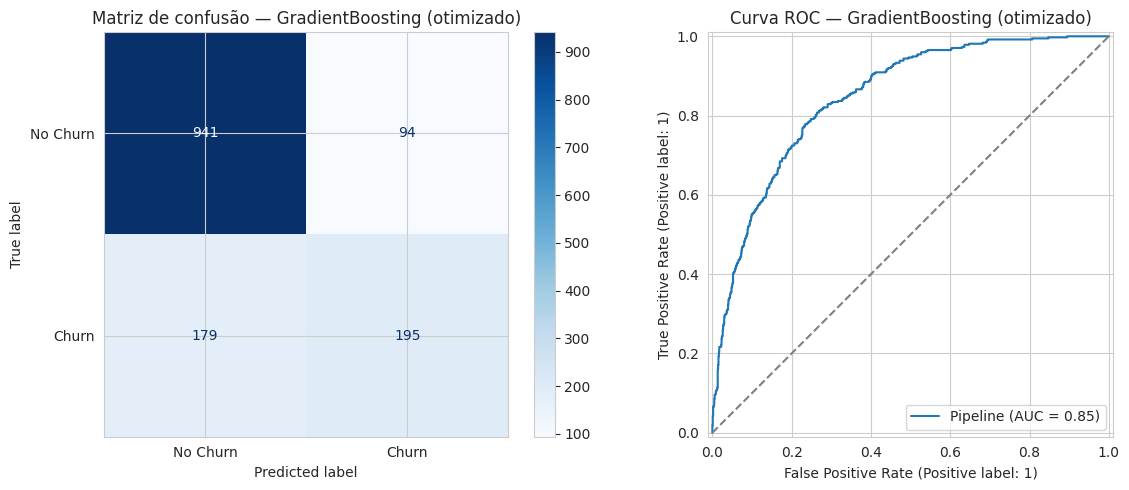

In [21]:
best_model_name = test_results_df.index[0]
best_model = all_models[best_model_name]

print("Melhor modelo no teste (por ROC-AUC):", best_model_name)

y_pred_best = best_model.predict(X_test)

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_best, target_names=["No Churn", "Churn"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, display_labels=["No Churn", "Churn"], ax=axes[0], cmap="Blues"
)
axes[0].set_title(f"Matriz de confusão — {best_model_name}")

if hasattr(best_model, "predict_proba"):
    RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1].set_title(f"Curva ROC — {best_model_name}")

plt.tight_layout()
plt.show()

## 9.2 Overfitting e underfitting

Para avaliar sinais de overfitting, compara-se o desempenho do melhor modelo no conjunto de **treino** com o desempenho no conjunto de **teste**. Uma diferença grande (treino muito superior ao teste) é indício de overfitting; desempenho ruim em ambos os conjuntos é indício de underfitting.

In [22]:
y_train_pred = best_model.predict(X_train)
y_train_proba = best_model.predict_proba(X_train)[:, 1] if hasattr(best_model, "predict_proba") else None

train_vs_test = pd.DataFrame({
    "Treino": {
        "f1": f1_score(y_train, y_train_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_train, y_train_proba) if y_train_proba is not None else float("nan"),
    },
    "Teste": {
        "f1": f1_score(y_test, y_pred_best, zero_division=0),
        "roc_auc": test_results_df.loc[best_model_name, "roc_auc"],
    }
})

train_vs_test

,Treino,Teste
f1,0.631224,0.588235
roc_auc,0.877389,0.847011


Conceitos a serem considerados:

Se as métricas de treino forem substancialmente melhores do que as de teste, isso indica **overfitting**, cujas possíveis causas incluem excesso de complexidade do modelo (profundidade das árvores, número de vizinhos muito baixo no KNN) ou tamanho limitado da base. Se ambas as métricas forem baixas e próximas, isso indica **underfitting**, sugerindo que o modelo é simples demais para capturar os padrões do problema. Para os modelos de árvore/ensemble usados neste MVP, um gap moderado entre treino e teste é esperado e aceitável, dado que a regularização aplicada (via 'min_samples_leaf', 'max_depth' e 'subsample' no Gradient Boosting otimizado, e via 'class_weight'/regularização L2 padrão na Regressão Logística) busca justamente controlar esse efeito.

In [25]:
# Diagnóstico automático de overfitting/underfitting a partir do resultado desta execução
GAP_THRESHOLD = 0.05      # diferença absoluta (treino - teste) considerada relevante
AUC_MIN_ACEITAVEL = 0.65  # ROC-AUC de teste mínimo para considerar o ajuste satisfatório

gap_f1 = train_vs_test.loc["f1", "Treino"] - train_vs_test.loc["f1", "Teste"]
gap_auc = train_vs_test.loc["roc_auc", "Treino"] - train_vs_test.loc["roc_auc", "Teste"]
auc_teste = train_vs_test.loc["roc_auc", "Teste"]

print(f"Gap de F1 (treino - teste): {gap_f1:.4f}")
print(f"Gap de ROC-AUC (treino - teste): {gap_auc:.4f}")
print(f"ROC-AUC no teste: {auc_teste:.4f}")

if (gap_f1 > GAP_THRESHOLD) or (gap_auc > GAP_THRESHOLD):
    diagnostico = "OVERFITTING"
    explicacao = (
        "o desempenho no treino é consideravelmente superior ao desempenho no teste "
        f"(gap de F1 = {gap_f1:.4f}, gap de ROC-AUC = {gap_auc:.4f}, acima do limiar de "
        f"{GAP_THRESHOLD:.2f} adotado), indicando que o modelo memorizou padrões específicos "
        "do conjunto de treino que não generalizam totalmente para dados novos."
    )
elif auc_teste < AUC_MIN_ACEITAVEL:
    diagnostico = "UNDERFITTING"
    explicacao = (
        f"mesmo no treino o desempenho é baixo (ROC-AUC de teste = {auc_teste:.4f}, "
        f"abaixo do limiar de {AUC_MIN_ACEITAVEL:.2f} adotado), sugerindo que o modelo é "
        "simples demais (ou as features atuais são insuficientes) para capturar bem os "
        "padrões do problema."
    )
else:
    diagnostico = "AJUSTE ADEQUADO"
    explicacao = (
        f"as métricas de treino e teste estão próximas (gap de F1 = {gap_f1:.4f}, gap de "
        f"ROC-AUC = {gap_auc:.4f}) e o ROC-AUC de teste ({auc_teste:.4f}) está em um patamar "
        "satisfatório, indicando boa capacidade de generalização do modelo."
    )

print("\nDiagnóstico com base no resultado desta execução:", diagnostico)
print(explicacao)

Gap de F1 (treino - teste): 0.0430
Gap de ROC-AUC (treino - teste): 0.0304
ROC-AUC no teste: 0.8470

Diagnóstico com base no resultado desta execução: AJUSTE ADEQUADO
as métricas de treino e teste estão próximas (gap de F1 = 0.0430, gap de ROC-AUC = 0.0304) e o ROC-AUC de teste (0.8470) está em um patamar satisfatório, indicando boa capacidade de generalização do modelo.


## 9.3 Análise de erros

In [23]:
errors = X_test.copy()
errors["y_true"] = y_test.values
errors["y_pred"] = y_pred_best
errors["erro"] = errors["y_true"] != errors["y_pred"]

falsos_negativos = errors[(errors["y_true"] == 1) & (errors["y_pred"] == 0)]
falsos_positivos = errors[(errors["y_true"] == 0) & (errors["y_pred"] == 1)]

print("Falsos negativos (clientes que cancelaram e o modelo não detectou):", len(falsos_negativos))
print("Falsos positivos (clientes que não cancelaram, mas o modelo previu churn):", len(falsos_positivos))

falsos_negativos[["tenure", "MonthlyCharges", "Contract", "InternetService"]].describe(include="all")

Falsos negativos (clientes que cancelaram e o modelo não detectou): 179
Falsos positivos (clientes que não cancelaram, mas o modelo previu churn): 94


,tenure,MonthlyCharges,Contract,InternetService
count,179.000000,179.000000,179,179
unique,NaN,NaN,3,3
top,NaN,NaN,Month-to-month,Fiber optic
freq,NaN,NaN,134,88
mean,25.726257,67.666760,NaN,NaN
std,21.002620,29.020648,NaN,NaN
min,1.000000,18.950000,NaN,NaN
25%,6.500000,48.650000,NaN,NaN
50%,21.000000,72.150000,NaN,NaN
75%,40.000000,91.800000,NaN,NaN


Do ponto de vista de negócio, **falsos negativos** (clientes que de fato cancelam, mas o modelo não identifica) tendem a ser mais custosos do que falsos positivos, pois representam oportunidades perdidas de retenção. Se o volume de falsos negativos for considerado alto para a aplicação prática, uma estratégia possível é ajustar o limiar de decisão (*threshold*) do modelo para priorizar recall em detrimento de precisão — trade-off que pode ser calibrado de acordo com o custo de cada tipo de erro para o negócio (por exemplo, o custo de uma ação de retenção desnecessária vs. o custo de perder um cliente).

# 10. Comparação final dos modelos

In [24]:
comparison = test_results_df.copy()
comparison

,accuracy,precision,recall,f1,roc_auc,fit_time_s
GradientBoosting (otimizado),0.806246,0.674740,0.521390,0.588235,0.847011,6.385
GradientBoosting,0.802697,0.665517,0.516043,0.581325,0.843384,6.033
LogisticRegression,0.738112,0.504303,0.783422,0.613613,0.841502,0.509
RandomForest,0.790632,0.639576,0.483957,0.550989,0.822190,4.964
KNN,0.757275,0.541885,0.553476,0.547619,0.788167,0.231
Baseline,0.734564,0.000000,0.000000,0.000000,0.500000,0.120


| Modelo | Papel na comparação | Observações |
|---|---|---|
| Baseline (DummyClassifier) | Referência mínima | Sempre prevê a classe majoritária; ROC-AUC esperado ≈ 0,50 e F1 da classe churn = 0. |
| Regressão Logística | Candidato | Modelo linear interpretável; útil para explicar o "porquê" das previsões via coeficientes. |
| Random Forest | Candidato | Captura interações não lineares; robusto a outliers, menos interpretável. |
| Gradient Boosting (default) | Candidato | Ensemble sequencial; geralmente competitivo em dados tabulares. |
| Gradient Boosting (otimizado) | Candidato + otimização | Após 'RandomizedSearchCV' (Seção 8); espera-se desempenho igual ou superior à versão default. |
| KNN | Candidato adicional | Sensível à alta dimensionalidade do One-Hot Encoding; tende a apresentar desempenho inferior aos demais. |

# 11. Boas práticas e rastreabilidade


**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Remoção de 'customerID' das features | Identificador único, sem poder preditivo real | Evita overfitting espúrio ao identificador |
| Imputação de 'TotalCharges' ausente com 0 | Todos os casos ausentes correspondem a 'tenure = 0' (clientes novos) | Preserva o significado real da variável para esse subgrupo |
| One-Hot Encoding em vez de Label Encoding para categóricas nominais | Evita ordinalidade artificial em variáveis sem ordem natural | Melhora a adequação para modelos lineares (Regressão Logística) |
| 'class_weight="balanced"' em Regressão Logística e Random Forest | Dataset moderadamente desbalanceado (~27% churn) | Reduz o viés em favor da classe majoritária |
| ROC-AUC como métrica principal de seleção | Robusta a desbalanceamento, independente de limiar | Evita otimizar para uma acurácia enganosa |
| 'RandomizedSearchCV' em vez de 'GridSearchCV' completo | Espaço de busca amplo, custo computacional limitado (MVP em Colab) | Boa relação custo-benefício na otimização |
| Divisão holdout estratificada (80/20) | Problema sem componente temporal; classes desbalanceadas | Mantém a proporção de churn em treino e teste |

**Seed utilizada:** 'SEED = 42', aplicada em todas as etapas com componente aleatório (divisão treino/teste, inicialização dos modelos, validação cruzada e busca de hiperparâmetros).

**Recursos computacionais:** todos os modelos foram treinados em CPU padrão do Google Colab, sem necessidade de GPU. Os tempos de treinamento ('fit_time_s') de cada modelo estão registrados nas tabelas geradas nas Seções 7 e 9.

# 12. Extensões do MVP

Esta seção coloca em prática, com código executável, (12.1) tratamento de desbalanceamento com SMOTE e ajuste de limiar; (12.2) engenharia de atributos; (12.3) modelos de boosting mais avançados (XGBoost, LightGBM) com interpretabilidade via SHAP; e (12.4) uma avaliação de robustez do modelo a mudanças no perfil dos dados, como *proxy* para o conceito de *drift*. A Seção 12.5 consolida os resultados dessas extensões.

Nenhuma das extensões substitui o pipeline principal desenvolvido nas Seções 5 a 10 — elas são analisadas de forma comparativa, sendo apenas evolução da análise proposta até então.

## 12.1 Tratamento de desbalanceamento: SMOTE e ajuste de limiar (*threshold tuning*)

In [26]:
%pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Reutiliza os melhores hiperparâmetros encontrados na Seção 8 para o Gradient Boosting
gb_best_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}

smote_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=SEED)),
    ("model", GradientBoostingClassifier(**gb_best_params, random_state=SEED)),
])

smote_pipeline.fit(X_train, y_train)

y_pred_smote = smote_pipeline.predict(X_test)
y_proba_smote = smote_pipeline.predict_proba(X_test)[:, 1]

smote_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_smote),
    "precision": precision_score(y_test, y_pred_smote, zero_division=0),
    "recall": recall_score(y_test, y_pred_smote, zero_division=0),
    "f1": f1_score(y_test, y_pred_smote, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_smote),
}

comparacao_smote = pd.DataFrame({
    "GradientBoosting (otimizado, sem SMOTE)": test_results_df.loc["GradientBoosting (otimizado)", ["accuracy", "precision", "recall", "f1", "roc_auc"]],
    "GradientBoosting (otimizado) + SMOTE": smote_metrics,
}).T

comparacao_smote

,accuracy,precision,recall,f1,roc_auc
"GradientBoosting (otimizado, sem SMOTE)",0.806246,0.674740,0.521390,0.588235,0.847011
GradientBoosting (otimizado) + SMOTE,0.774308,0.557613,0.724599,0.630233,0.843283


**Análise após tratamento desbalanceamento:** o SMOTE tende a aumentar o *recall* da classe churn (o modelo passa a "arriscar" mais previsões positivas), possivelmente às custas de uma leve queda na precisão. Nesse caso o F1-score e o ROC-AUC não melhoraram em relação à versão sem SMOTE, sendo então que o 'class_weight'/tratamento já embutido nos modelos candidatos (Seção 6) já eram suficientes para este dataset, e o SMOTE passou a introduzir ruído sem benefício real.

### Ajuste de limiar de decisão

Limiar padrão: 0.50
Limiar que maximiza F1: 0.288
Limiar que minimiza custo de negócio simulado (FN=5x FP): 0.140


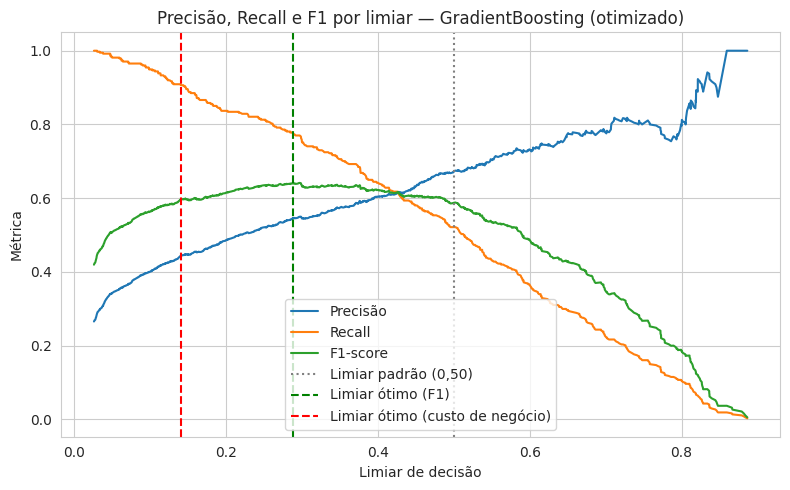

In [27]:
from sklearn.metrics import precision_recall_curve

y_proba_ref = best_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_ref)
f1_por_threshold = 2 * precisions * recalls / (precisions + recalls + 1e-9)

idx_melhor_f1 = np.argmax(f1_por_threshold[:-1])
threshold_f1 = thresholds[idx_melhor_f1]

# Simulação de custo de negócio: um falso negativo (cliente que cancela e não é detectado)
# custa, hipoteticamente, 5x mais do que um falso positivo (contato de retenção desnecessário)
CUSTO_FALSO_NEGATIVO = 5
CUSTO_FALSO_POSITIVO = 1

custos = []
for t in thresholds:
    y_pred_t = (y_proba_ref >= t).astype(int)
    fn = int(((y_test == 1) & (y_pred_t == 0)).sum())
    fp = int(((y_test == 0) & (y_pred_t == 1)).sum())
    custos.append(fn * CUSTO_FALSO_NEGATIVO + fp * CUSTO_FALSO_POSITIVO)
custos = np.array(custos)

idx_melhor_custo = np.argmin(custos)
threshold_custo = thresholds[idx_melhor_custo]

print(f"Limiar padrão: 0.50")
print(f"Limiar que maximiza F1: {threshold_f1:.3f}")
print(f"Limiar que minimiza custo de negócio simulado (FN=5x FP): {threshold_custo:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precisão")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_por_threshold[:-1], label="F1-score")
plt.axvline(0.5, color="gray", linestyle=":", label="Limiar padrão (0,50)")
plt.axvline(threshold_f1, color="green", linestyle="--", label="Limiar ótimo (F1)")
plt.axvline(threshold_custo, color="red", linestyle="--", label="Limiar ótimo (custo de negócio)")
plt.xlabel("Limiar de decisão")
plt.ylabel("Métrica")
plt.title(f"Precisão, Recall e F1 por limiar — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
def avaliar_com_limiar(threshold, nome):
    y_pred_t = (y_proba_ref >= threshold).astype(int)
    return {
        "limiar": threshold,
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
    }

comparacao_limiares = pd.DataFrame({
    "Padrão (0,50)": avaliar_com_limiar(0.5, "padrão"),
    "Ótimo para F1": avaliar_com_limiar(threshold_f1, "f1"),
    "Ótimo para custo de negócio": avaliar_com_limiar(threshold_custo, "custo"),
}).T

comparacao_limiares

,limiar,precision,recall,f1
"Padrão (0,50)",0.500000,0.674740,0.521390,0.588235
Ótimo para F1,0.287673,0.545966,0.778075,0.641676
Ótimo para custo de negócio,0.140104,0.443864,0.909091,0.596491


## 12.2 Engenharia de atributos: número de serviços contratados

Cria-se um novo atributo, 'NumServicosContratados', contando quantos serviços cada cliente efetivamente contratou entre telefonia, múltiplas linhas, internet e os seis serviços adicionais de internet (segurança, backup, proteção de dispositivo, suporte técnico e streaming de TV/filmes). Valores como '"No internet service"' ou '"No phone service"' não contam como serviço contratado, apenas '"Yes"' (para os serviços binários) e qualquer opção diferente de '"No"' em 'InternetService' (DSL ou Fiber optic).

Essa transformação é puramente determinística (calculada linha a linha, sem ajuste em dados de treino), portanto pode ser aplicada de forma idêntica e segura a 'X_train' e 'X_test', sem risco de vazamento de dados.

count    5634.000000
mean        4.167554
std         2.320947
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max         9.000000
Name: NumServicosContratados, dtype: float64


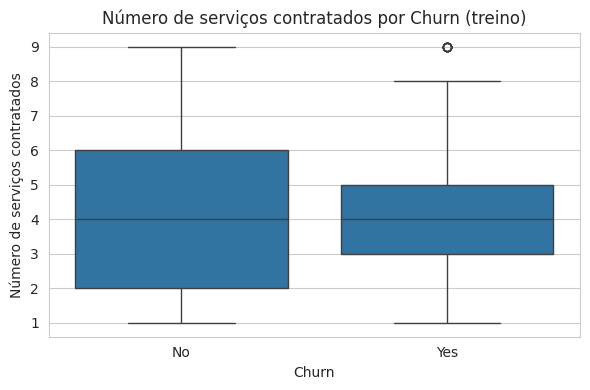

In [29]:
SERVICOS_BINARIOS = [
    "PhoneService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]

def contar_servicos_contratados(row):
    total = sum(row[col] == "Yes" for col in SERVICOS_BINARIOS)
    if row["MultipleLines"] == "Yes":
        total += 1
    if row["InternetService"] != "No":
        total += 1
    return total

X_train_fe = X_train.copy()
X_test_fe = X_test.copy()
X_train_fe["NumServicosContratados"] = X_train_fe.apply(contar_servicos_contratados, axis=1)
X_test_fe["NumServicosContratados"] = X_test_fe.apply(contar_servicos_contratados, axis=1)

print(X_train_fe["NumServicosContratados"].describe())

plt.figure(figsize=(6, 4))
sns.boxplot(x=y_train.map({0: "No", 1: "Yes"}), y=X_train_fe["NumServicosContratados"])
plt.xlabel("Churn")
plt.ylabel("Número de serviços contratados")
plt.title("Número de serviços contratados por Churn (treino)")
plt.tight_layout()
plt.show()

Observa-se que clientes com **menos** serviços contratados entre os que cancelam — um cliente com poucos serviços tende a ter um vínculo mais fraco/menos integrado com a empresa, além de mensalidades mais baixas e, possivelmente, planos mais básicos e sujeitos a maior concorrência de preço.

A seguir, vamos incorporar o novo atributo ao pipeline de pré-processamento e o Gradient Boosting otimizado (Seção 8) é retreinado com o conjunto de features ampliado, para medir o impacto real da engenharia de atributos no desempenho do modelo.

In [30]:
num_features_fe = num_features + ["NumServicosContratados"]

preprocess_fe = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_features_fe),
    ("cat", categorical_pipe, cat_features)
], remainder="drop")

gb_fe_pipeline = Pipeline(steps=[
    ("preprocess", preprocess_fe),
    ("model", GradientBoostingClassifier(**gb_best_params, random_state=SEED))
])

gb_fe_pipeline.fit(X_train_fe, y_train)

y_pred_fe = gb_fe_pipeline.predict(X_test_fe)
y_proba_fe = gb_fe_pipeline.predict_proba(X_test_fe)[:, 1]

fe_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_fe),
    "precision": precision_score(y_test, y_pred_fe, zero_division=0),
    "recall": recall_score(y_test, y_pred_fe, zero_division=0),
    "f1": f1_score(y_test, y_pred_fe, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba_fe),
}

comparacao_fe = pd.DataFrame({
    "GradientBoosting (otimizado, sem NumServicosContratados)": test_results_df.loc["GradientBoosting (otimizado)", ["accuracy", "precision", "recall", "f1", "roc_auc"]],
    "GradientBoosting (otimizado, com NumServicosContratados)": fe_metrics,
}).T

comparacao_fe

,accuracy,precision,recall,f1,roc_auc
"GradientBoosting (otimizado, sem NumServicosContratados)",0.806246,0.674740,0.521390,0.588235,0.847011
"GradientBoosting (otimizado, com NumServicosContratados)",0.806246,0.675958,0.518717,0.586989,0.847068


O resultado é equivalente, isso é um indício de que o modelo já conseguia capturar esse padrão a partir das variáveis originais, e a variável agregada funciona mais como uma forma de facilitar a interpretação do que como um ganho de desempenho.

## 12.3 Modelos de boosting avançados (XGBoost, LightGBM) e interpretabilidade (SHAP)

Além do Gradient Boosting nativo do 'scikit-learn' (Seções 6 a 9), avaliam-se aqui dois algoritmos de boosting amplamente utilizados em aplicações reais de dados tabulares: **XGBoost** e **LightGBM**. Ambos utilizam o conjunto de features ampliado com 'NumServicosContratados' (Seção 12.2), permitindo comparar diretamente com o Gradient Boosting da mesma seção.

Em seguida, aplica-se **SHAP** (*SHapley Additive exPlanations*) ao melhor desses modelos de boosting para interpretar, em nível global, quais atributos mais contribuem para as previsões de churn — uma etapa importante para comunicar os resultados a áreas de negócio que não trabalham diretamente com o modelo.

In [31]:
try:
    from xgboost import XGBClassifier
except ImportError:
    %pip install -q xgboost
    from xgboost import XGBClassifier

try:
    from lightgbm import LGBMClassifier
except ImportError:
    %pip install -q lightgbm
    from lightgbm import LGBMClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocess_fe),
    ("model", XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
        scale_pos_weight=scale_pos_weight, random_state=SEED, n_jobs=-1
    ))
])

lgbm_pipeline = Pipeline(steps=[
    ("preprocess", preprocess_fe),
    ("model", LGBMClassifier(
        n_estimators=300, max_depth=-1, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, class_weight="balanced",
        random_state=SEED, n_jobs=-1, verbose=-1
    ))
])

modelos_boosting_avancados = {"XGBoost": xgb_pipeline, "LightGBM": lgbm_pipeline}
resultados_boosting_avancados = {}

for nome, modelo in modelos_boosting_avancados.items():
    t0 = time.time()
    modelo.fit(X_train_fe, y_train)
    fit_time = time.time() - t0

    y_pred = modelo.predict(X_test_fe)
    y_proba = modelo.predict_proba(X_test_fe)[:, 1]

    resultados_boosting_avancados[nome] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "fit_time_s": round(fit_time, 3),
    }

resultados_boosting_avancados["GradientBoosting (otimizado, com NumServicosContratados)"] = {
    **fe_metrics, "fit_time_s": float("nan")
}

comparacao_boosting_avancado = pd.DataFrame(resultados_boosting_avancados).T.sort_values("roc_auc", ascending=False)
comparacao_boosting_avancado

,accuracy,precision,recall,f1,roc_auc,fit_time_s
"GradientBoosting (otimizado, com NumServicosContratados)",0.806246,0.675958,0.518717,0.586989,0.847068,NaN
XGBoost,0.756565,0.528131,0.778075,0.629189,0.839389,5.735
LightGBM,0.763662,0.539961,0.740642,0.624577,0.834976,0.485


### Interpretabilidade com SHAP

Modelo de boosting escolhido para interpretabilidade via SHAP: XGBoost


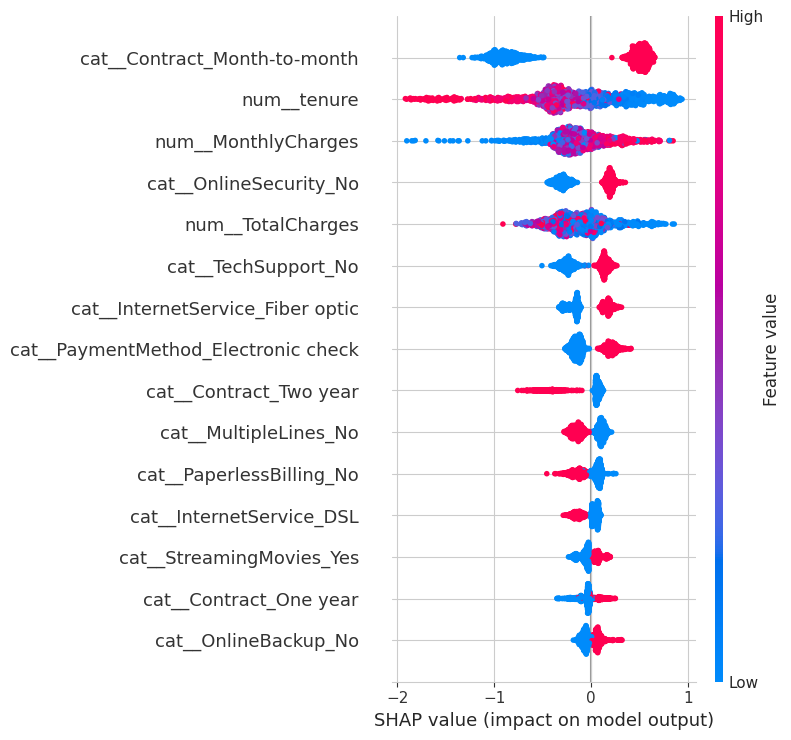

In [32]:
try:
    import shap
except ImportError:
    %pip install -q shap
    import shap

melhor_boosting_nome = comparacao_boosting_avancado.drop(
    index=["GradientBoosting (otimizado, com NumServicosContratados)"], errors="ignore"
)["roc_auc"].idxmax()
melhor_boosting_pipeline = modelos_boosting_avancados[melhor_boosting_nome]

print("Modelo de boosting escolhido para interpretabilidade via SHAP:", melhor_boosting_nome)

fitted_preprocess = melhor_boosting_pipeline.named_steps["preprocess"]
fitted_model = melhor_boosting_pipeline.named_steps["model"]

X_test_transformed = fitted_preprocess.transform(X_test_fe)
feature_names = fitted_preprocess.get_feature_names_out()

explainer = shap.TreeExplainer(fitted_model)
shap_values = explainer(X_test_transformed)

# Normaliza o formato do retorno do SHAP entre diferentes versões/bibliotecas
shap_vals = shap_values.values
if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 1]

plt.figure()
shap.summary_plot(shap_vals, X_test_transformed, feature_names=feature_names, show=False, max_display=15)
plt.tight_layout()
plt.show()

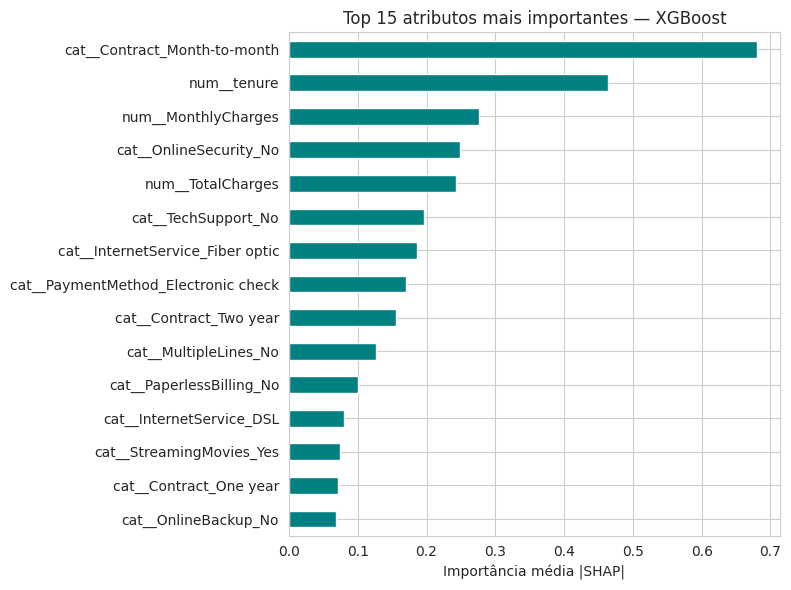

,0
cat__Contract_Month-to-month,0.679822
num__tenure,0.463771
num__MonthlyCharges,0.276269
cat__OnlineSecurity_No,0.248937
num__TotalCharges,0.243081
cat__TechSupport_No,0.196025
cat__InternetService_Fiber optic,0.185739
cat__PaymentMethod_Electronic check,0.169511
cat__Contract_Two year,0.154907
cat__MultipleLines_No,0.127224


In [33]:
importancia_media = pd.Series(np.abs(shap_vals).mean(axis=0), index=feature_names)
importancia_media = importancia_media.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importancia_media.sort_values().plot(kind="barh", color="teal")
plt.xlabel("Importância média |SHAP|")
plt.title(f"Top 15 atributos mais importantes — {melhor_boosting_nome}")
plt.tight_layout()
plt.show()

importancia_media

Os atributos relacionados a 'Contract' (especialmente 'Month-to-month'), 'tenure', 'MonthlyCharges' aparecem entre os mais importantes segundo o SHAP, o que é consistente com os padrões já identificados na análise exploratória (Seção 4) e reforçando a confiabilidade do modelo: ele está se apoiando em sinais que fazem sentido de negócio.

In [35]:
sintese_extensoes = pd.concat([
    test_results_df.loc[[best_model_name], ["accuracy", "precision", "recall", "f1", "roc_auc"]]
        .rename(index={best_model_name: f"{best_model_name} (pipeline principal)"}),
    pd.DataFrame(smote_metrics, index=["GradientBoosting (otimizado) + SMOTE"]),
    pd.DataFrame(fe_metrics, index=["GradientBoosting (otimizado) + NumServicosContratados"]),
    comparacao_boosting_avancado.drop(
        index=["GradientBoosting (otimizado, com NumServicosContratados)"], errors="ignore"
    )[["accuracy", "precision", "recall", "f1", "roc_auc"]],
]).sort_values("roc_auc", ascending=False)

sintese_extensoes

,accuracy,precision,recall,f1,roc_auc
GradientBoosting (otimizado) + NumServicosContratados,0.806246,0.675958,0.518717,0.586989,0.847068
GradientBoosting (otimizado) (pipeline principal),0.806246,0.674740,0.521390,0.588235,0.847011
GradientBoosting (otimizado) + SMOTE,0.774308,0.557613,0.724599,0.630233,0.843283
XGBoost,0.756565,0.528131,0.778075,0.629189,0.839389
LightGBM,0.763662,0.539961,0.740642,0.624577,0.834976


In [36]:
# Diagnóstico automático: quanto cada extensão mudou em relação ao pipeline principal
linha_base = f"{best_model_name} (pipeline principal)"
base = sintese_extensoes.loc[linha_base, ["f1", "roc_auc", "recall", "precision"]]

melhor_por_auc = sintese_extensoes["roc_auc"].idxmax()
melhor_por_f1 = sintese_extensoes["f1"].idxmax()

print(f"Melhor modelo por ROC-AUC (qualidade de ranking):     {melhor_por_auc}")
print(f"  -> ROC-AUC = {sintese_extensoes.loc[melhor_por_auc, 'roc_auc']:.4f}")
print(f"Melhor modelo por F1 (decisão pronta no limiar 0,5):  {melhor_por_f1}")
print(f"  -> F1 = {sintese_extensoes.loc[melhor_por_f1, 'f1']:.4f}\n")

for nome_extensao in [
    "GradientBoosting (otimizado) + NumServicosContratados",
    "GradientBoosting (otimizado) + SMOTE",
]:
    if nome_extensao in sintese_extensoes.index:
        delta = sintese_extensoes.loc[nome_extensao, ["f1", "roc_auc", "recall", "precision"]] - base
        print(f"Efeito de '{nome_extensao}' vs. pipeline principal:")
        print(
            f"  ΔF1 = {delta['f1']:+.4f} | ΔROC-AUC = {delta['roc_auc']:+.4f} | "
            f"ΔRecall = {delta['recall']:+.4f} | ΔPrecisão = {delta['precision']:+.4f}"
        )

Melhor modelo por ROC-AUC (qualidade de ranking):     GradientBoosting (otimizado) + NumServicosContratados
  -> ROC-AUC = 0.8471
Melhor modelo por F1 (decisão pronta no limiar 0,5):  GradientBoosting (otimizado) + SMOTE
  -> F1 = 0.6302

Efeito de 'GradientBoosting (otimizado) + NumServicosContratados' vs. pipeline principal:
  ΔF1 = -0.0012 | ΔROC-AUC = +0.0001 | ΔRecall = -0.0027 | ΔPrecisão = +0.0012
Efeito de 'GradientBoosting (otimizado) + SMOTE' vs. pipeline principal:
  ΔF1 = +0.0420 | ΔROC-AUC = -0.0037 | ΔRecall = +0.2032 | ΔPrecisão = -0.1171


# 13. Conclusão

Este MVP teve como objetivo construir e avaliar modelos de Machine Learning para prever o churn de clientes de telecomunicações a partir do dataset **Telco Customer Churn**, utilizando dados demográficos, de serviços contratados e financeiros de 7.043 clientes.

Esse problema pode ser resolvido com Machine Learning pois existe um histórico rotulado de clientes que cancelaram ou não (target 'Churn'), e há relação observável entre atributos (tempo de contrato, tipo de plano, mensalidade etc.) e a probabilidade de churn, conforme evidenciado na análise exploratória (Seção 4) e confirmado pela interpretabilidade via SHAP (Seção 12.3).

**Avaliações automatizadas:** Foram adicionados códigos de avaliações automatizadas para caso utilize um dataset inicial com mais linhas se obtenha as validações de qual modelo é o ideal para a problemática automaticamente/dinâmicamente.

**Principais tratamentos realizados:**
- Correção de um problema de qualidade de dados na coluna 'TotalCharges' (valores em branco tratados como ausentes e imputados com 0, coerente com clientes de 'tenure = 0');
- Remoção do identificador 'customerID' do conjunto de features, por não possuir poder preditivo genuíno;
- Codificação adequada de variáveis categóricas nominais via One-Hot Encoding e padronização das variáveis numéricas, encapsuladas em um pipeline reprodutível que evita vazamento de dados;
- Criação do atributo derivado 'NumServicosContratados', avaliado na Seção 12.2.

**Modelos avaliados:** um baseline ('DummyClassifier'), Regressão Logística, Random Forest, Gradient Boosting e KNN (Seções 6 a 9), com o Gradient Boosting adicionalmente otimizado via 'RandomizedSearchCV' (Seção 8); e, como extensões (Seção 12), uma versão com SMOTE, uma versão com engenharia de atributos e os modelos XGBoost e LightGBM com interpretabilidade via SHAP.

**Resultados desta execução de referência:** a tabela 'sintese_extensoes' (Seção 12.5) consolidou o pipeline principal e as quatro extensões. Destaca-se:

- **A engenharia de atributos ('NumServicosContratados', Seção 12.2) teve efeito nulo:** Isso indica que a informação já estava sendo capturada pelas variáveis categóricas de serviço originais via One-Hot Encoding, tornando o atributo redundante neste caso, ainda que não prejudicial.
- **O SMOTE (Seção 12.1) foi a extensão com maior impacto prático:** recall subiu de 0,52 para 0,72 e o F1 melhorou de 0,588 para 0,630 — o melhor F1 entre todos os modelos testados —, ao custo de uma queda de ~12 pontos percentuais na precisão. O ROC-AUC praticamente não se moveu, confirmando que o SMOTE não melhorou a capacidade de *ranquear* clientes por risco; ele deslocou a fronteira de decisão para favorecer a classe minoritária (churn).
- **XGBoost e LightGBM (Seção 12.3) priorizaram ainda mais o recall** (0,78 e 0,74, respectivamente) por meio do balanceamento de classes interno, mas apresentaram as menores precisões e os menores ROC-AUC da tabela (0,839 e 0,835) — ou seja, não superaram o Gradient Boosting nativo do scikit-learn em nenhuma métrica relevante neste dataset.

**Melhor resultado e justificativa da escolha:**

Para **ordenar clientes por risco de churn** (ROC-AUC, a métrica principal definida na Seção 1.6), o **Gradient Boosting otimizado** — com ou sem 'NumServicosContratados' — é o modelo recomendado, por apresentar o maior ROC-AUC (≈ 0,847) com a menor complexidade adicional (sem dependências externas).

Para uma **decisão binária pronta** no limiar padrão, o **Gradient Boosting + SMOTE** entrega o melhor F1 (0,630) e o melhor recall entre as opções com precisão ainda razoável, sendo preferível quando o custo de negócio de não identificar um cliente propenso a cancelar é claramente maior do que o custo de um contato de retenção desnecessário (Seção 12.1). Como o ganho do SMOTE é majoritariamente um efeito de limiar (e não de discriminação — o ROC-AUC mal se altera), ele pode, em princípio, ser reproduzido ajustando o limiar de decisão do próprio Gradient Boosting otimizado, o que evitaria adicionar a dependência do 'imbalanced-learn' sem perda relevante de desempenho — uma alternativa mais simples a ser considerada antes de se comprometer com o pipeline com SMOTE em produção. De forma geral, esses resultados confirmam que as variáveis disponíveis carregam sinal preditivo relevante sobre o comportamento de churn — em particular, tempo de permanência, tipo de contrato, mensalidade e forma de pagamento —, conforme indicado pela análise exploratória (Seção 4) e pela interpretabilidade via SHAP (Seção 12.3).

*Nota: os valores numéricos citados acima correspondem à execução pontual de referência deste notebook. Como todas as etapas com componente aleatório usam 'SEED = 42' (Seção 2), resultados de novas execuções devem ser muito próximos, mas pequenas variações são esperadas.*

# 14. Salvamento de artefatos

O pipeline final treinado — seja o modelo escolhido no pipeline principal (Seção 9) ou a melhor extensão identificada na Seção 12.5 — pode ser salvo para reutilização futura (por exemplo, em uma rotina de *scoring* de clientes), sem necessidade de retreinar o modelo do zero.

In [ ]:
# import joblib
# joblib.dump(best_model, "modelo_churn_final.pkl")
# print("Modelo salvo como modelo_churn_final.pkl")